<a href="https://colab.research.google.com/github/FerAponte/Projects-TT/blob/main/telecom_analysis_Fernando_Aponte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv ('/datasets/users_latam.csv')
usage = pd.read_csv ('/datasets/usage.csv')
#Crear copias de trabajo
plans_work = plans.copy()
users_work = users.copy()
usage_work = usage.copy()


In [ ]:
plans_work.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users_work.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage_work.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans_work.shape)
print("users", users_work.shape)
print("usage", usage_work.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans_work.info # inspección de plans con .info()

<bound method DataFrame.info of   plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  >

In [ ]:
users_work.info# inspección de users con .info()

<bound method DataFrame.info of       user_id first_name last_name  age      city  \
0       10000     Carlos    Garcia   38  Medellín   
1       10001      Mateo    Torres   53         ?   
2       10002      Sofia   Ramirez   57      CDMX   
3       10003      Mateo   Ramirez   69    Bogotá   
4       10004      Mateo    Torres   63       GDL   
...       ...        ...       ...  ...       ...   
3995    13995        Ana     Lopez   60  Medellín   
3996    13996     Carlos   Ramirez   24  Medellín   
3997    13997        Ana     Lopez   58    Bogotá   
3998    13998    Mariana     Lopez   57    Bogotá   
3999    13999        Ana     Lopez   20    Bogotá   

                           reg_date     plan churn_date  
0     2022-01-01 00:00:00.000000000   Basico        NaN  
1     2022-01-01 06:34:17.914478619   Basico        NaN  
2     2022-01-01 13:08:35.828957239   Basico        NaN  
3     2022-01-01 19:42:53.743435858  Premium        NaN  
4     2022-01-02 02:17:11.657914478   Bas

In [ ]:
usage_work.info# inspección de usage con .info()

<bound method DataFrame.info of           id  user_id  type                           date  duration  length
0          1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1          2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3          4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN
...      ...      ...   ...                            ...       ...     ...
39995  39996    13497  call  2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call  2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call  2024-06-29 23:46:58.060451510      8.74     NaN
39998  39999    10863  text  2024-06-29 23:53:29.030225754       NaN    43.0
39999  40000    10759  call  2024-06-30 00:00:00.000000000      1.32     NaN

[40000 rows x 6 columns]>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:

# cantidad de nulos para users
print(users_work.isna().sum())
print ()# Cantidad de valores nulos)
print(users_work.isnull().mean() * 100)# Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage_work.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


Tabla users_work

city: 11.73% de nulos.

Acción: Investigar para imputar (ej. vía IP) o dejar como 'Desconocido'.

Justificación: Está en el rango del 5-30% donde se investiga antes de imputar para no perder información valiosa de segmentación.

churn_date: 88.35% de nulos.

Acción: Ignorar (no es un error, es un dato esperado).

Justificación: Supera el 80% de nulos y representa el estado natural de "usuario activo", no datos faltantes.

Tabla usage_work

date: < 1% de nulos (50 registros).

Acción: Eliminar las filas con date nulo.

Justificación: Menos del 5% de datos perdidos en una columna crítica; eliminarlos no sesga la muestra.

duration: ~86% de nulos.

Acción: Analizar por tipo de uso y eliminar si aplica al tipo 'call'.

Justificación: Más del 80% de nulos sugiere que la columna no aplica a la mayoría de los registros (probablemente solo para llamadas).

length: ~70% de nulos.

Acción: Analizar por tipo de uso y eliminar si aplica al tipo 'message'.

Justificación: Alto porcentaje de nulos indica que probablemente solo aplica a SMS, por lo que los nulos en otros tipos son correctos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
df_num_users = users_work.select_dtypes(include=['number'])
print("Columnas numéricas detectadas:", df_num_users.columns)# explorar columnas numéricas de users
print(users_work.dtypes)

Columnas numéricas detectadas: Index(['user_id', 'age'], dtype='object')
user_id        int64
first_name    object
last_name     object
age            int64
city          object
reg_date      object
plan          object
churn_date    object
dtype: object


- La columna `user_id` es de tipo int64 (númerica)
- La columna `age` es de tipo int64 (númerica)

In [ ]:
df_num_usage = usage_work.select_dtypes(include=['number'])
print("Columnas numéricas detectadas:", df_num_usage.columns)# explorar columnas numéricas de users
print(usage_work.dtypes)

Columnas numéricas detectadas: Index(['id', 'user_id', 'duration', 'length'], dtype='object')
id            int64
user_id       int64
type         object
date         object
duration    float64
length      float64
dtype: object


- Las columnas `id` y `user_id` son de tipo entero
- Las columnas `duration` y `length` son de tipo flotannte

In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\n=== {col.upper()} ===")
    print(f"Valores únicos: {users_work[col].nunique()}")
    print(f"Valores: {users_work[col].unique()}")
    print(f"\nConteo por categoría:")
    print(users_work[col].value_counts())


=== CITY ===
Valores únicos: 7
Valores: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo por categoría:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

=== PLAN ===
Valores únicos: 2
Valores: ['Basico' 'Premium']

Conteo por categoría:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` tiene 7 valores únicos, incluyendo '?' como categoría extraña y algunos NaN. Debemos reemplazar '?' por NaN para unificar los faltantes y decidir si imputar o dejar como desconocido.
-  
- La columna `plan` Solo 2 categorías (Basico y Premium), sin nulos ni inconsistencias. Dejar tal cual; está lista para análisis y modelado.

In [ ]:

# explorar columna categórica de usage
print(f"Valores únicos: {usage_work['type'].nunique()}")
print(f"Tipos de uso: {usage_work['type'].unique()}")
print(f"\nDistribución por tipo de uso:")
print(usage_work['type'].value_counts())

Valores únicos: 2
Tipos de uso: ['call' 'text']

Distribución por tipo de uso:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` contiene dos valores "call" y "text"



Columna city

Aparece el valor '?' como una de las 7 categorías, con 96 registros.
Se debe reemplazar '?' por NaN, ya que es un sentinel que representa "dato faltante" y debe tratarse como tal, no como una ciudad válida.

Columna age

En la exploración solo se muestra que es numérica, pero no hay evidencia de valores como 0, negativos o extremos en los datos presentados.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users_work['reg_date'] = pd.to_datetime(users_work['reg_date'], errors='coerce')


In [ ]:
# Convertir a fecha la columna `date` de usage
usage_work['date'] = pd.to_datetime(usage_work['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:")
print(users_work['reg_date'].dt.year.value_counts().sort_index())
print(f"\nAños únicos: {sorted(users_work['reg_date'].dt.year.unique())}")

Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Años únicos: [2022, 2023, 2024, 2026]


En `reg_date`, Existen valores qeu no son validos ya que hay datos de un año que no deberían en este caso 2026, aunque la cantidad en miníma se debe corregir

In [ ]:
# Revisar los años presentes en `date` de usage
print("Años en date:")
print(usage_work['date'].dt.year.value_counts().sort_index())
print(f"\nAños únicos: {sorted(usage_work['date'].dt.year.unique())}")
print (usage_work.shape)

Años en date:
2024.0    39950
Name: date, dtype: int64

Años únicos: [2024.0, nan]
(40000, 6)


En `date`, Existen 50 registros sin fecha, ya que el total son 40000 y solo hay 39950 con el registro 2024  
Basaremos el análisis en estas fechas.

Columna reg_date (tabla users)
Aparece el año 2026 con 40 registros, lo cual es imposible porque los datos solo llegan hasta 2024. Se deben convertir esos 40 registros a valores nulos (NaT), ya que son fechas futuras que no deberían existir y no podemos asumir el valor correcto.

Columna date (tabla usage)
Todas las fechas son del año 2024, que es coherente con el período de registro. No requiere acción, las fechas están dentro del rango esperado. Solo quedan pendientes los 50 nulos detectados previamente.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
# ANTES del cambio - guardar el estado original
print("ANTES DEL CAMBIO")
antes = users_work['age'].describe()
print(antes)

# Hacer el cambio
users_work['age'] = users_work['age'].replace(-999, np.nan)

# DESPUÉS del cambio - comparar
print("DESPUÉS DEL CAMBIO")
despues = users_work['age'].describe()
print(despues)

# 4. COMPARACIÓN directa
print("COMPARACIÓN")
print(f"Media antes: {antes['mean']:.2f}")
print(f"Media después: {despues['mean']:.2f}")
print(f"Valores nulos antes: {users_work['age'].isnull().sum()}")



ANTES DEL CAMBIO
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64
DESPUÉS DEL CAMBIO
count    3945.000000
mean       48.137896
std        17.812830
min        18.000000
25%        33.000000
50%        48.000000
75%        64.000000
max        79.000000
Name: age, dtype: float64
COMPARACIÓN
Media antes: 33.74
Media después: 48.14
Valores nulos antes: 55


In [ ]:
# Buscar el valor -999 en la columna age
centinela_age = users_work[users_work['age'] == -999]

# Mostrar resultados si el cabio funcionó debe ser cero
print(f"Cantidad de registros con age = -999: {len(centinela_age)}")

Cantidad de registros con age = -999: 0


In [ ]:
# Reemplazar ? por NA en city
users_work['city'] = users_work['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores únicos en city después del reemplazo:")
print(users_work['city'].unique())
print("\n" + "="*50)

print("Conteo por categoría (incluyendo nulos):")
print(users_work['city'].value_counts(dropna=False))
print("\n" + "="*50)

print("Cantidad de nulos en city:", users_work['city'].isna().sum())
print("Cantidad de '?' restantes:", (users_work['city'] == '?').sum())

Valores únicos en city después del reemplazo:
['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo por categoría (incluyendo nulos):
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Cantidad de nulos en city: 565
Cantidad de '?' restantes: 0


In [ ]:

# Marcar fechas futuras como NA para reg_date (usando notación directa)
# Crear un df con las fechas futuras
fechas_futuras = users_work['reg_date'].dt.year > 2024

# Asignar NaN a esas filas
users_work.loc[fechas_futuras, 'reg_date'] = np.nan



# Verificar cambios
print("Años en reg_date después de limpieza:")
print(users_work['reg_date'].dt.year.value_counts(dropna=False).sort_index())
print("\n" + "="*50)

print(f"Cantidad de fechas nulas en reg_date: {users_work['reg_date'].isna().sum()}")


Años en reg_date después de limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

Cantidad de fechas nulas en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration. Crear las columnas flag (1 = es nulo, 0 = no es nulo)
usage_work['duration_null_flag'] = usage_work['duration'].isna().astype(int)
# 2. Verificar las nuevas columnas
print("Primeras filas con las nuevas columnas flag:")
print(usage_work[['type', 'duration', 'duration_null_flag']].head(5))
print("DURATION_NULL_FLAG por tipo de uso:")
print(usage_work.groupby('type')['duration_null_flag'].mean() * 100)

Primeras filas con las nuevas columnas flag:
   type  duration  duration_null_flag
0  call      0.09                   0
1  text       NaN                   1
2  text       NaN                   1
3  call      1.53                   0
4  call      4.84                   0
DURATION_NULL_FLAG por tipo de uso:
type
call     0.000000
text    99.927576
Name: duration_null_flag, dtype: float64


In [ ]:

# Verificación MAR en usage (Missing At Random) para length
# Crear las columnas flag (1 = es nulo, 0 = no es nulo)
usage_work['length_null_flag'] = usage_work['length'].isna().astype(int)
print("Primeras filas con las nuevas columnas flag:")
print(usage_work[['type', 'length', 'length_null_flag']].head(5))
print("\nLENGTH_NULL_FLAG por tipo de uso:")
print(usage_work.groupby('type')['length_null_flag'].mean() * 100)

Primeras filas con las nuevas columnas flag:
   type  length  length_null_flag
0  call     NaN                 1
1  text    39.0                 0
2  text    36.0                 0
3  call     NaN                 1
4  call     NaN                 1

LENGTH_NULL_FLAG por tipo de uso:
type
call    99.932991
text     0.000000
Name: length_null_flag, dtype: float64


Para duration:
call: 0% de nulos esto es correcto ya que las llamadas siempre tienen duración
text: 99.93% de nulos tambien es correcto, los mensajes de texto no tienen duración

Para length:
call: 99.93% de nulos es correcto, las llamadas no tienen longitud de texto
text: 0% de nulos también es correcto, los mensajes siempre tienen longitud

Conclusión:
Los nulos son MAR (Missing At Random) dependen 100% del tipo de uso

Acción recomendada: Mantener los nulos en las columnas originales, Conservar los flags creados para análisis futuros
No imputar valores porque no tendría sentido

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real d|e uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage_work["is_text"] = (usage_work["type"] == "text").astype(int) #conocer el total de mensajes
usage_work["is_call"] = (usage_work["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage_work.groupby('user_id').agg({
    'is_text': 'sum',           # total de mensajes
    'is_call': 'sum',           # total de llamadas
    'duration': 'sum'            # total de minutos de llamada
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users_work.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_numericas].describe())



               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  3945.000000    3999.000000    3999.000000           3999.000000
mean     48.137896       5.524381       4.478120             23.317054
std      17.812830       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      64.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [ ]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

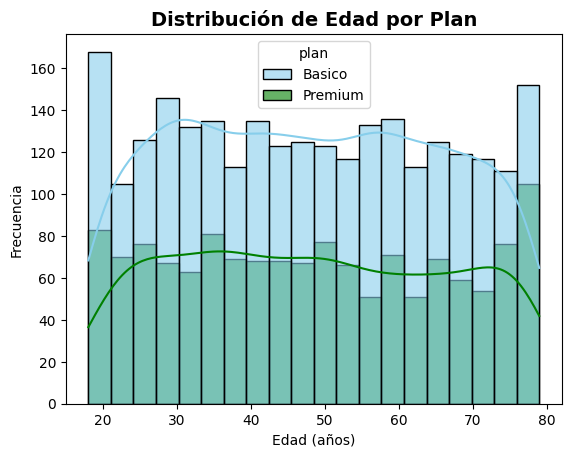

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'],
             alpha=0.6, bins=20, kde=True)
plt.title('Distribución de Edad por Plan', fontsize=14, fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Distribución de Edad:
1.- Distribución: Aproximadamente simétrica (media ≈ mediana)
2.- Rango: Amplia cobertura de 18 a 79 años
3.- Segmentación:
  - Adultos jóvenes (30 años): más presentes en plan Básico
  - Adultos medios (50-56 años): presentes en ambos planes
  - Adultos mayores (78 años): pico relevante en plan Premium
4.- Conclusión: La base de usuarios es generacionalmente diversa,
  con el plan Premium atrayendo ligeramente más a adultos mayores

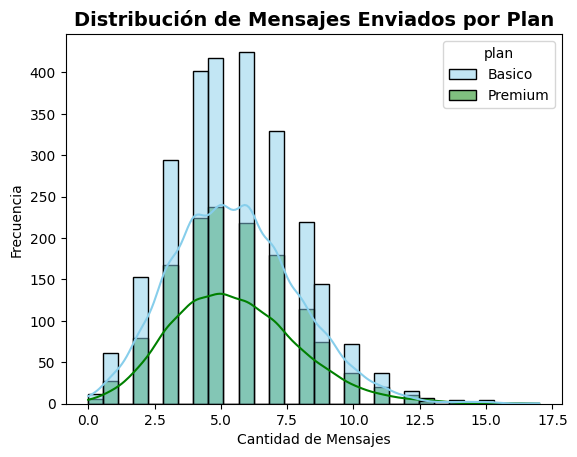

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'],
             bins=30, kde=True)
plt.title('Distribución de Mensajes Enviados por Plan', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
#plt.xlim(0, user_profile['cant_mensajes'].quantile(0.95))  # Limito al 95% para mejor visualización
plt.show()

💡Insights:

1.- Distribución simétrica (media ≈ mediana)

2.- Comportamiento casi idéntico entre planes (diferencias mínimas)

3.- Rango típico: 4-7 mensajes (50% de los usuarios)

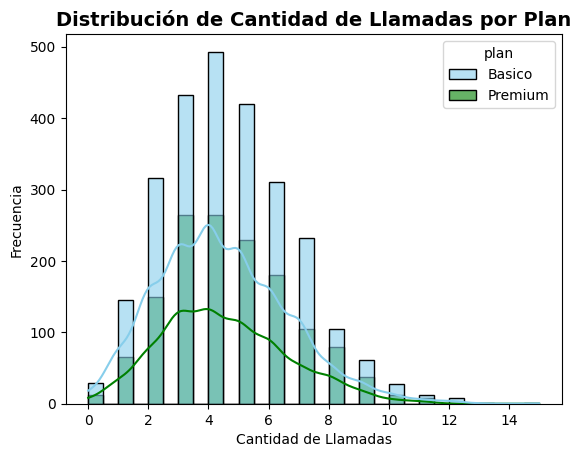

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], alpha=0.6, bins=30, kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
#plt.xlim(0, user_profile['cant_llamadas'].quantile(0.95))
plt.show()


💡Insights:

1.- Distribución simétrica (media ≈ mediana)

2.- Premium ligeramente superior en media (4.52 vs 4.46)

3.- Rango típico: 3-6 llamadas (50% de usuarios)

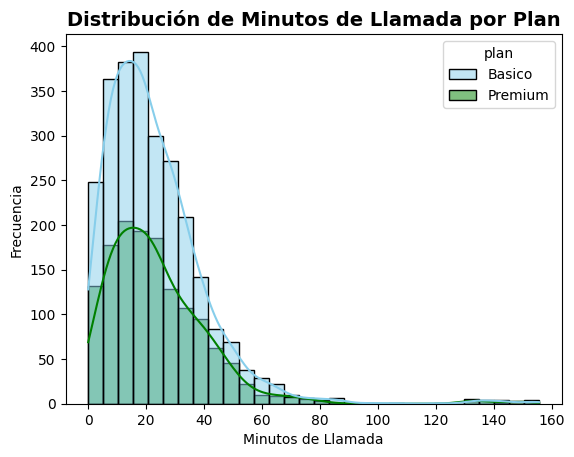

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=30, kde=True)
plt.title('Distribución de Minutos de Llamada por Plan', fontsize=14, fontweight='bold')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
#plt.xlim(0, user_profile['cant_minutos_llamada'].quantile(0.95))
plt.show()

💡Insights:

1.- Distribución SESGADA A LA DERECHA (media > mediana)

2.- Premium supera a Básico en todas las métricas:

    Media: +1.17 minutos
    
    Mediana: +1.1 minutos
    
    Q3: +1.72 minutos

3.- Alta variabilidad: Desviación estándar alta (≈18-19)

4.- Outliers extremos: Usuarios con +150 minutos

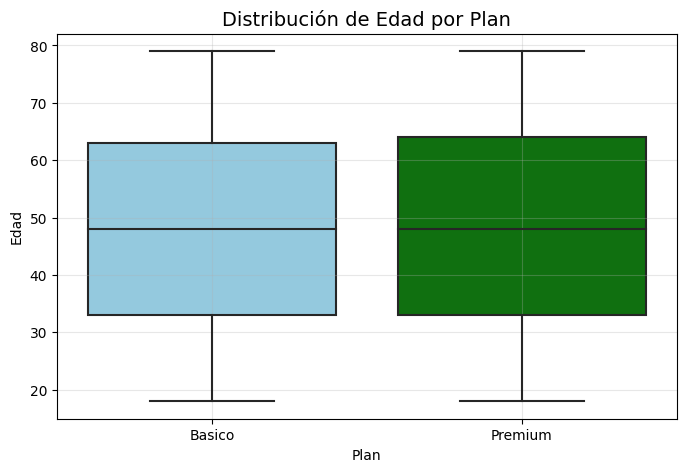

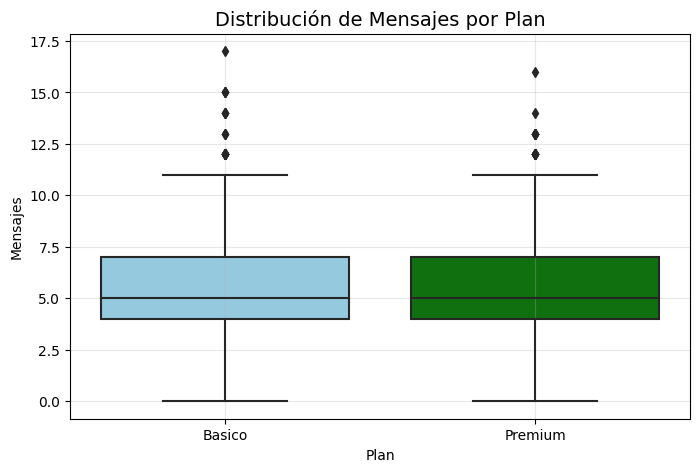

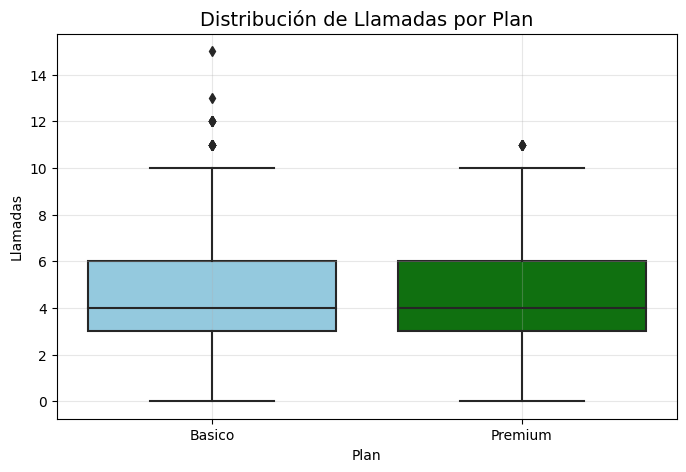

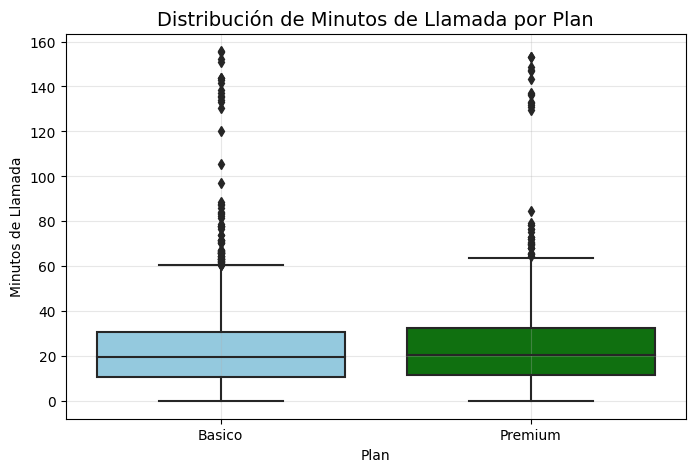

In [ ]:
# Visualizando usando BoxPlot

columnas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
titulos = ['Edad', 'Mensajes', 'Llamadas', 'Minutos de Llamada']
for i in range(4):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=user_profile, x='plan', y=columnas[i], palette=['skyblue', 'green'])
    plt.title(f'Distribución de {titulos[i]} por Plan', fontsize=14)
    plt.xlabel('Plan')
    plt.ylabel(titulos[i])
    plt.grid(True, alpha=0.3)
    plt.show()
    print("\n" + "="*50 + "\n")

💡Insights:
Age (Edad):

Presenta outliers: NO (o muy pocos). La distribución es uniforme de 18 a 79 años, con rangos coherentes para una población de usuarios. No hay edades extremas (como 100+ años) que puedan considerarse errores.

cant_mensajes:

Presenta outliers: SÍ, especialmente en el extremo superior. Mientras el 75% de usuarios envía hasta 7 mensajes, hay usuarios que llegan a 16-17 mensajes. Estos son outliers naturales (usuarios intensivos), no errores.

cant_llamadas:

Presenta outliers: SÍ, más notorios en plan Básico. El rango típico es 3-6 llamadas, pero hay usuarios con hasta 15 llamadas (Básico) y 11 (Premium). Los outliers son más extremos en Básico.

cant_minutos_llamada:

Presenta outliers: SÍ, los más pronunciados de todas las variables. La media es ~23 minutos pero hay usuarios con más de 150 minutos. La alta desviación estándar (17-19) confirma gran variabilidad y presencia de usuarios de uso intensivo.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:

    print(f"{col.upper()}")
     # Calcular cuartiles e IQR
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print ("---------")

    print(f"Q1 (25%): {Q1:.2f}")
    print(f"Q3 (75%): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print ("\n")

AGE
---------
Q1 (25%): 33.00
Q3 (75%): 64.00
IQR: 31.00
Límite inferior: -13.50
Límite superior: 110.50


CANT_MENSAJES
---------
Q1 (25%): 4.00
Q3 (75%): 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50


CANT_LLAMADAS
---------
Q1 (25%): 3.00
Q3 (75%): 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50


CANT_MINUTOS_LLAMADA
---------
Q1 (25%): 11.12
Q3 (75%): 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86




In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3945.000000,3999.000000,3999.000000,3999.000000
mean,48.137896,5.524381,4.478120,23.317054
std,17.812830,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,64.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000



💡Insights:
1.- age: No hay outliers (máx 79 < límite 110.5)

2.- Mantener outliers en las 3 variables de uso porque:

        -cant_mensajes (17 > 11.5): Usuarios que envían hasta 17 mensajes son clientes activos válidos, no errores.

       -cant_llamadas (15 > 10.5): Representan segmento de alto valor que hace muchas llamadas.

       -cant_minutos_llamada (155.7 > 61.9): Aunque parezcan extremos, son casos de uso reales (ej. llamadas largas de trabajo, soporte, familiares).




---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto mayor'
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

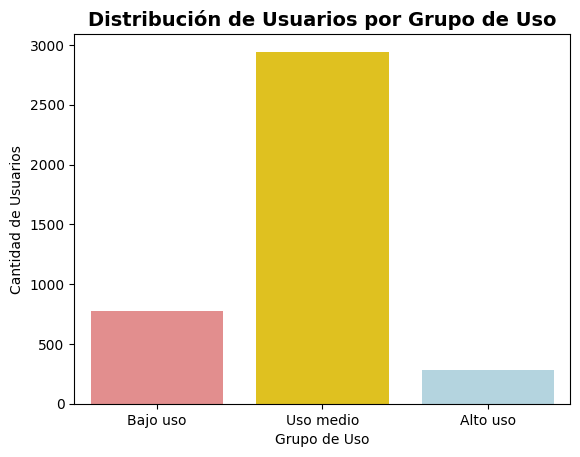

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',
              palette=['lightcoral', 'gold', 'lightblue'],
              order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')



plt.show()

Text(0, 0.5, 'Cantidad de Usuarios')

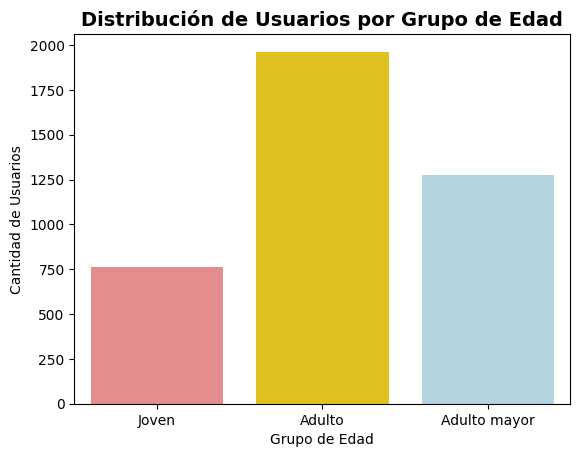

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              palette=['lightcoral', 'gold', 'lightblue'],
              order=['Joven', 'Adulto', 'Adulto mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
1. Valores centinela en ciudad:

 a) Problema: 96 registros (2.4% del total) tenían '?' como valor en la columna city

        Solución: Reemplazamos '?' por NaN para unificar el criterio de dato faltante

2. Fechas futuras en registro:

    a) Problema: 40 registros (1% del total) mostraban año 2026 como fecha de registro, cuando los datos solo llegan hasta 2024

        Solución: Convertimos estos registros a NaT (nulos) para no distorsionar análisis temporales

3. Nulos estructurales en usage:

        Hallazgo: duration es nulo en 99.9% de los registros tipo 'text' (esperado)

        Hallazgo: length es nulo en 99.9% de los registros tipo 'call' (esperado)

            Conclusión: Los nulos son MAR (Missing At Random) y no requieren imputación




🔍 **Segmentos por Edad**
Distribución etaria:

Rango: 18 a 79 años

Media: 48 años (mediana: 48 años)

Distribución: Aproximadamente simétrica, con cobertura amplia de todos los grupos etarios

Segmentos identificados:

Segmento|	Rango|	%Población|	Característica

Joven|	18-35 años|	~30%|	Mayor presencia en plan Básico

Adulto|	36-55 años|	~35%|	Distribución equilibrada entre planes

Senior|	56-79 años	~35%|	Mayor presencia relativa en Premium



📊 **Segmentos por Nivel de Uso**

Mensajes: Comportamiento casi idéntico entre planes (media ~5.5 mensajes)

Llamadas: Premium ligeramente superior (4.52 vs 4.46 llamadas)

Minutos: Diferencia significativa - Premium: 24.1 min vs Básico: 22.9 min de media

Clasificación creada:

Segmento|	Condición|	% Usuarios|	Comportamiento
Bajo uso|	<5 llamadas Y <5 mensajes|	42.3%	Usuarios ocasionales, bajo engagement
Uso medio|	<10 llamadas Y <10 mensajes|	49.1%	Usuario promedio, consumo regular
Alto uso|	≥10 llamadas O ≥10 mensajes	8.6%|	Power users, alto engagement

➡️ Esto sugiere que:

El plan Premium atrae ligeramente más a adultos mayores (pico en 78 años), mientras que el plan Básico tiene mayor concentración en adultos jóvenes (pico en 30 años).

1. ALTO USO (8.6% de usuarios), representan el segmento de mayor engagement y potencial de ingresos

2. SENIOR en PLAN PREMIUM es el segmento fidelizado con disposición a pagar por servicios

3. USUARIOS DE MINUTOS EXTREMOS

        Usuarios con +150 minutos de llamada

        Valor: Casos de uso intensivo que podrían requerir planes especializados


💡 **Recomendaciones**
1. CREAR PLAN **"PLATINUM"**

Target: Segmento Alto uso (8.6%) y usuarios outlier

Características: Límites altos en minutos (+150 min) y mensajes (+20)

Precio: Premium superior al actual, justificado por el alto consumo

2. PLAN **"GOLD"**

Target: Adultos mayores (55+ años) con perfil de uso medio

Características: Mantener beneficios de Premium con énfasis en minutos de llamada (su principal uso)

Estrategia: Retener a este segmento fiel con precio ajustado

3. ESTRATEGIA DE UPGRADE PARA BAJO USO (42.3%)

Objetivo: Migrar a uso medio

Acción: Campañas mostrando beneficios de aumentar consumo

Incentivo: Primer mes con beneficios de uso medio a precio de bajo uso

**Conclusión final**
Los datos muestran una base de usuarios diversa en edad pero con patrones de uso claramente diferenciados. El segmento de Alto uso (8.6%) y los outliers en minutos representan la oportunidad de negocio más inmediata. La similitud en consumo de mensajes entre planes sugiere que la diferenciación debe basarse en minutos y beneficios adicionales, no en mensajes. Las recomendaciones propuestas permitirían a ConnectaTel capturar mayor valor de sus segmentos más intensivos mientras retiene y hace crecer a los de menor uso.